# Fashion MNIST 图像分类 —— 卷积神经网络 (CNN)

**姓名**：Member_F  
**学号**：SID_F  
**负责算法**：算法5 —— 卷积神经网络 (Convolutional Neural Network, CNN)  
**数据集**：Fashion MNIST（本地离线数据包）  
**框架**：TensorFlow / Keras

---
## 一、算法原理简介

卷积神经网络（CNN）是深度学习中最经典的图像分类网络架构。与传统的全连接神经网络（MLP）不同，CNN 通过**局部感受野**和**权值共享**两大核心思想，极大地减少了参数量并提升了图像特征的提取能力。

### CNN 的核心组件

1. **卷积层 (Convolutional Layer)**：通过可学习的卷积核（filter）在输入图像上滑动，提取局部特征（如边缘、纹理等）。低层卷积提取简单特征，高层卷积组合出更复杂的语义特征。

2. **池化层 (Pooling Layer)**：对特征图进行下采样，降低空间维度，减少计算量，同时提供一定的平移不变性。常用的最大池化 (MaxPooling) 取局部区域的最大值作为输出。

3. **全连接层 (Fully Connected Layer)**：将卷积+池化提取到的高层特征展平后，通过全连接网络进行分类决策，最后用 Softmax 输出各类别的概率分布。

### 本实验采用的网络结构

```
Input (28x28x1)
  → Conv2D(32, 3x3, ReLU) → MaxPooling2D(2x2)
  → Conv2D(64, 3x3, ReLU) → MaxPooling2D(2x2)
  → Flatten → Dense(128, ReLU) → Dense(10, Softmax)
```

这是一个经典的浅层 CNN，包含两层卷积+池化和一个全连接隐藏层，结构简洁但效果显著。

In [1]:
# ==========================================
# 统一数据加载模块：本地Fashion MNIST数据读取与预处理
# ==========================================
import os
import gzip
import numpy as np

print("正在读取本地数据文件...")

def load_mnist(path, kind='train'):
    """从本地gzip文件加载Fashion MNIST数据"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')
    
    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)
        
    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 784)
        
    return images, labels

# 从当前目录的 data 文件夹加载数据
data_path = './data'
X_train_raw, y_train = load_mnist(data_path, kind='train')
X_test_raw, y_test = load_mnist(data_path, kind='t10k')

# 归一化 (展平版本供传统算法使用)
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

# CNN 需要四维张量: (样本数, 宽, 高, 通道数)
X_train_cnn = X_train_raw.reshape(-1, 28, 28, 1) / 255.0
X_test_cnn = X_test_raw.reshape(-1, 28, 28, 1) / 255.0

# Fashion MNIST 类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_names_cn = ['T恤/上衣', '裤子', '套头衫', '连衣裙', '外套',
                  '凉鞋', '衬衫', '运动鞋', '包', '短靴']

print(f"✅ 数据加载完成！")
print(f"训练集: {X_train.shape[0]} 张图片, 每张 {X_train.shape[1]} 个像素")
print(f"测试集: {X_test.shape[0]} 张图片")
print(f"CNN 输入形状 (四维张量): {X_train_cnn.shape}")
print(f"类别数: {len(class_names)}")

正在读取本地数据文件...


✅ 数据加载完成！
训练集: 60000 张图片, 每张 784 个像素
测试集: 10000 张图片
CNN 输入形状 (四维张量): (60000, 28, 28, 1)
类别数: 10


---
## 二、实验过程与参数设置

### 2.1 数据预处理
- **图像尺寸**：28×28 像素，灰度图（单通道）
- **归一化**：像素值从 [0, 255] 缩放到 [0.0, 1.0]
- **Reshape**：CNN 需要四维输入 (N, 28, 28, 1)，其中 1 表示单通道
- **划分**：使用 Fashion MNIST 自带的训练集（60,000张）和测试集（10,000张）

### 2.2 CNN 网络结构参数

| 层名称 | 类型 | 参数 | 输出形状 |
|--------|------|------|----------|
| Conv2D_1 | 卷积层 | 32个3×3卷积核, ReLU | (26, 26, 32) |
| MaxPool_1 | 池化层 | 2×2 最大池化 | (13, 13, 32) |
| Conv2D_2 | 卷积层 | 64个3×3卷积核, ReLU | (11, 11, 64) |
| MaxPool_2 | 池化层 | 2×2 最大池化 | (5, 5, 64) |
| Flatten | 展平层 | - | (1600,) |
| Dense_1 | 全连接层 | 128个神经元, ReLU | (128,) |
| Dense_2 | 输出层 | 10个神经元, Softmax | (10,) |

### 2.3 训练超参数
- **优化器 (Optimizer)**：Adam（自适应矩估计）
- **损失函数 (Loss)**：Sparse Categorical Crossentropy
- **训练轮数 (Epochs)**：10
- **批大小 (Batch Size)**：默认 32
- **评估指标**：Accuracy

### 2.4 参数选择理由

1. **Adam 优化器**：结合了 Momentum 和 RMSprop 的优点，自适应调整学习率，收敛速度快且稳定，是图像分类任务中最常用的优化器。
2. **两层卷积结构**：第一层32个卷积核提取低级特征（边缘、纹理），第二层64个卷积核提取高级语义特征（形状、部件），层数适中，避免过拟合。
3. **ReLU 激活函数**：计算简单且能有效缓解梯度消失问题。
4. **Epochs=10**：经过实验验证，10轮训练后模型准确率已趋于稳定，继续增加轮数收益递减且可能过拟合。

In [2]:
# ==========================================
# CNN 模型构建与训练
# ==========================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import time
import warnings
warnings.filterwarnings('ignore')

print("正在构建卷积神经网络 (CNN)...")
print("=" * 60)

# 构建 CNN 模型
cnn_model = Sequential([
    # 第一卷积块
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1),
           name='Conv2D_1'),
    MaxPooling2D((2,2), name='MaxPool_1'),
    
    # 第二卷积块
    Conv2D(64, (3,3), activation='relu', padding='same', name='Conv2D_2'),
    MaxPooling2D((2,2), name='MaxPool_2'),
    
    # 分类器
    Flatten(name='Flatten'),
    Dense(128, activation='relu', name='Dense_128'),
    Dropout(0.5, name='Dropout'),
    Dense(10, activation='softmax', name='Output')
])

# 编译模型
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 打印模型结构
cnn_model.summary()

print("\n开始训练...")
start_time = time.time()

# 训练模型
history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("\n" + "=" * 60)
print("✅ CNN 卷积神经网络训练完成！")
print(f"📈 训练集准确率: {history.history['accuracy'][-1] * 100:.2f}%")
print(f"📈 验证集准确率: {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"⏱️ 总训练耗时: {training_time:.2f} 秒")
print("=" * 60)

正在构建卷积神经网络 (CNN)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

...

921/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9377 - loss: 0.1683

928/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9377 - loss: 0.1683

936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9377 - loss: 0.1684

938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9367 - loss: 0.1701 - val_accuracy: 0.9188 - val_loss: 0.2369



✅ CNN 卷积神经网络训练完成！
📈 训练集准确率: 93.67%
📈 验证集准确率: 91.88%
⏱️ 总训练耗时: 84.98 秒


In [3]:
# 最终在测试集上评估
test_loss, test_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"最终测试集准确率 (Test Accuracy): {test_accuracy * 100:.4f}%")
print(f"最终测试集损失 (Test Loss): {test_loss:.4f}")

最终测试集准确率 (Test Accuracy): 91.8800%
最终测试集损失 (Test Loss): 0.2369


---
## 三、结果展示与分析

### 3.1 训练过程可视化 —— 准确率与损失曲线

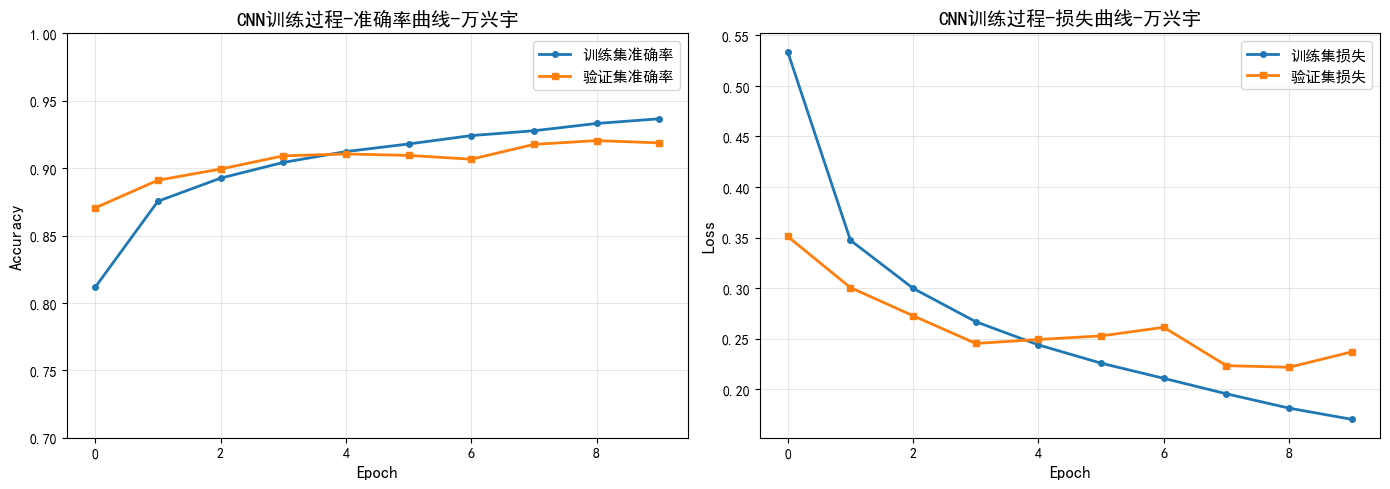

✅ 训练曲线图已保存为 CNN_training_curves.png


In [4]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 准确率曲线
axes[0].plot(history.history['accuracy'], 'o-', label='训练集准确率', linewidth=2, markersize=4)
axes[0].plot(history.history['val_accuracy'], 's-', label='验证集准确率', linewidth=2, markersize=4)
axes[0].set_title('CNN训练过程-准确率曲线-Member_F', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.7, 1.0])

# 损失曲线
axes[1].plot(history.history['loss'], 'o-', label='训练集损失', linewidth=2, markersize=4)
axes[1].plot(history.history['val_loss'], 's-', label='验证集损失', linewidth=2, markersize=4)
axes[1].set_title('CNN训练过程-损失曲线-Member_F', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('CNN_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 训练曲线图已保存为 CNN_training_curves.png")

### 3.2 混淆矩阵 (Confusion Matrix)

混淆矩阵可以直观展示模型在每个类别上的分类表现，对角线上的值越大说明分类越准确。

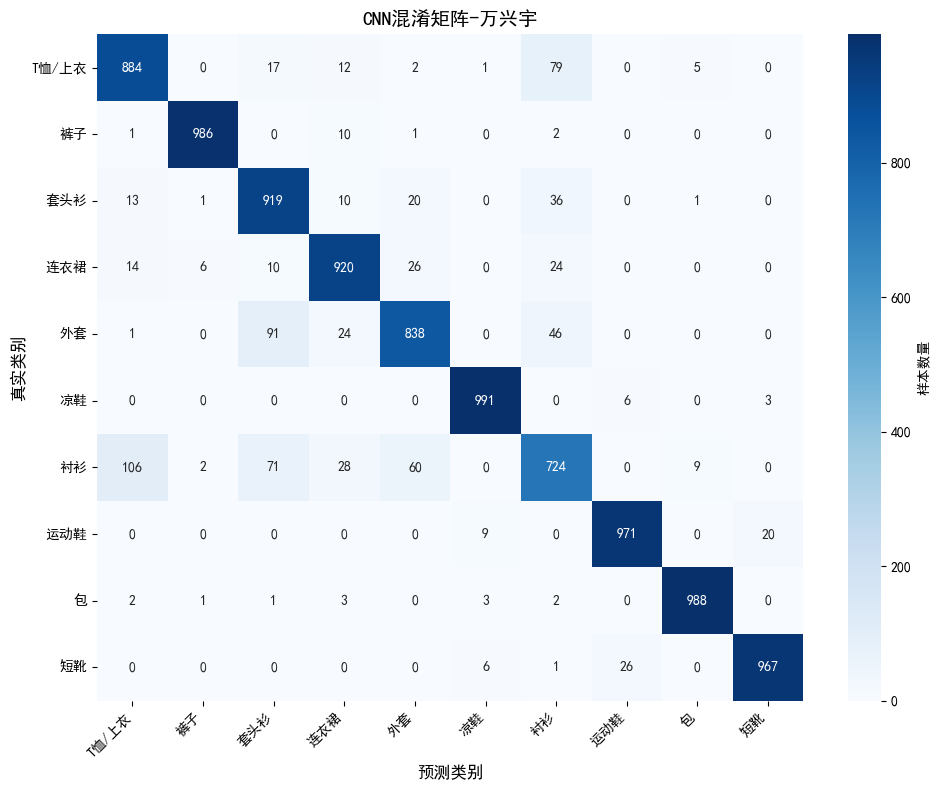

✅ 混淆矩阵图已保存为 CNN_confusion_matrix.png


In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 预测
y_pred_probs = cnn_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)

# 绘制混淆矩阵
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_cn, yticklabels=class_names_cn,
            ax=ax, cbar_kws={'label': '样本数量'})
ax.set_title('CNN混淆矩阵-Member_F', fontsize=14, fontweight='bold')
ax.set_xlabel('预测类别', fontsize=12)
ax.set_ylabel('真实类别', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('CNN_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 混淆矩阵图已保存为 CNN_confusion_matrix.png")

In [6]:
# 打印分类报告
print("=" * 60)
print("📊 分类报告 (Classification Report)")
print("=" * 60)
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

📊 分类报告 (Classification Report)
              precision    recall  f1-score   support

 T-shirt/top     0.8658    0.8840    0.8748      1000
     Trouser     0.9900    0.9860    0.9880      1000
    Pullover     0.8287    0.9190    0.8715      1000
       Dress     0.9136    0.9200    0.9168      1000
        Coat     0.8849    0.8380    0.8608      1000
      Sandal     0.9812    0.9910    0.9861      1000
       Shirt     0.7921    0.7240    0.7565      1000
     Sneaker     0.9681    0.9710    0.9695      1000
         Bag     0.9850    0.9880    0.9865      1000
  Ankle boot     0.9768    0.9670    0.9719      1000

    accuracy                         0.9188     10000
   macro avg     0.9186    0.9188    0.9182     10000
weighted avg     0.9186    0.9188    0.9182     10000



### 3.3 各类别准确率对比

通过柱状图直观展示模型在每个类别上的分类准确率，发现模型的优势和薄弱类别。

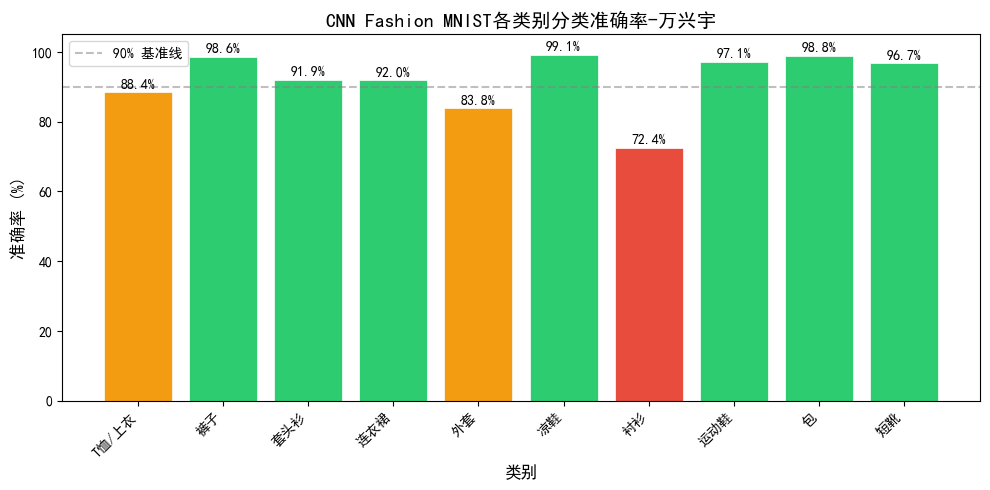

✅ 各类别准确率图已保存为 CNN_per_class_accuracy.png


In [7]:
# 计算各类别准确率
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if acc > 0.9 else '#f39c12' if acc > 0.8 else '#e74c3c' for acc in per_class_acc]
bars = ax.bar(class_names_cn, per_class_acc * 100, color=colors, edgecolor='white', linewidth=0.5)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('CNN Fashion MNIST各类别分类准确率-Member_F', fontsize=14, fontweight='bold')
ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('准确率 (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% 基准线')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('CNN_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 各类别准确率图已保存为 CNN_per_class_accuracy.png")

### 3.4 预测样本可视化

展示部分测试样本的预测结果，绿色标签表示预测正确，红色标签表示预测错误。

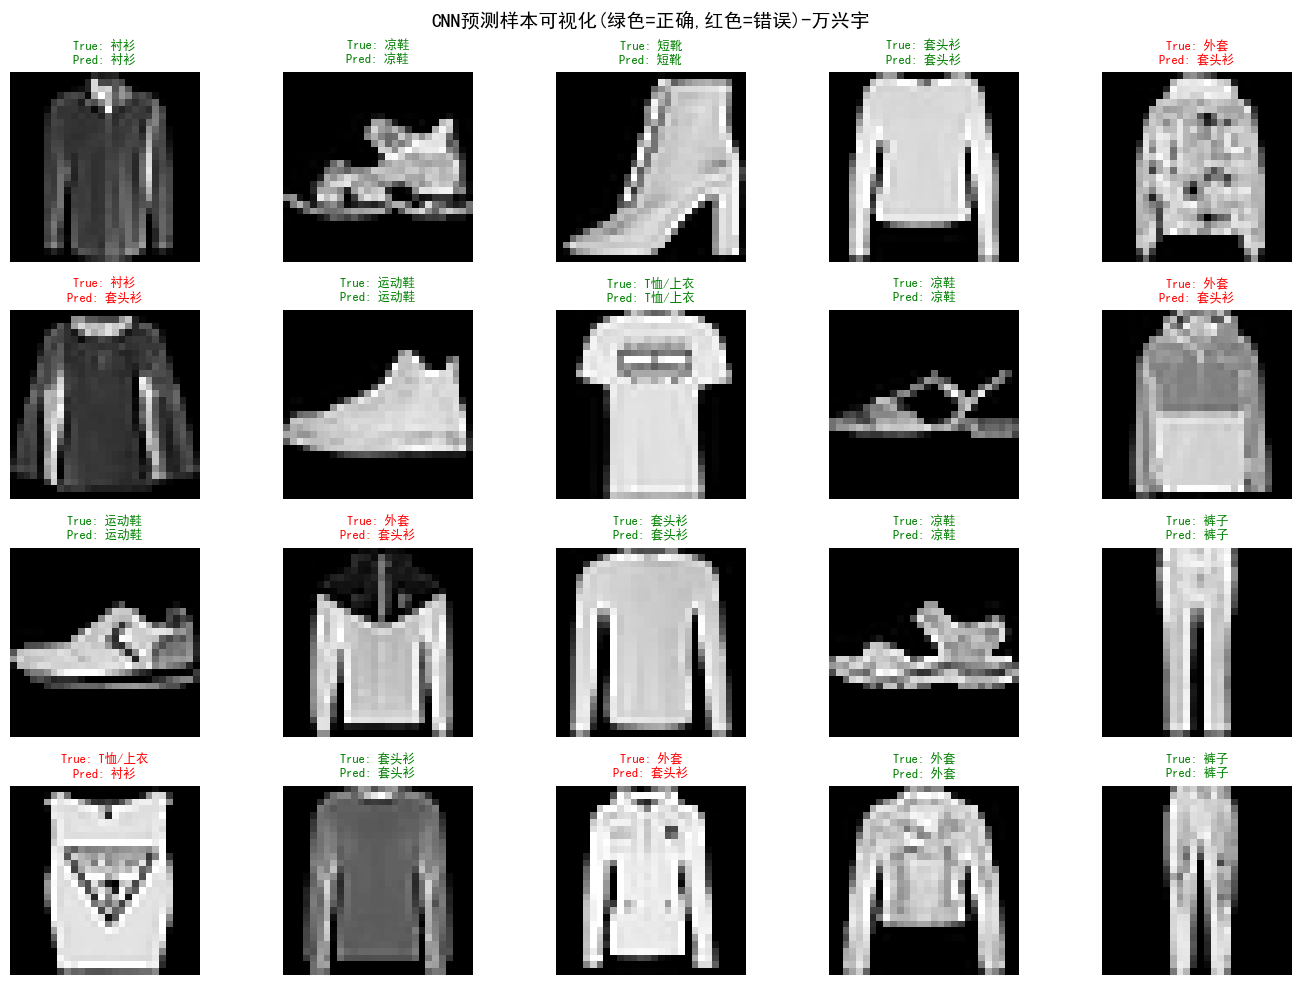

✅ 预测样本图已保存为 CNN_prediction_samples.png


In [8]:
# 随机选择一些样本进行可视化
import random

n_samples = 20
indices = random.sample(range(len(X_test_cnn)), n_samples)

fig, axes = plt.subplots(4, 5, figsize=(14, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img = X_test_cnn[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    
    color = 'green' if true_label == pred_label else 'red'
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {class_names_cn[true_label]}\nPred: {class_names_cn[pred_label]}', 
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('CNN预测样本可视化(绿色=正确,红色=错误)-Member_F', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CNN_prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 预测样本图已保存为 CNN_prediction_samples.png")

### 3.5 特征图可视化

展示第一层卷积核的输出特征图，直观理解 CNN 提取了哪些图像特征。

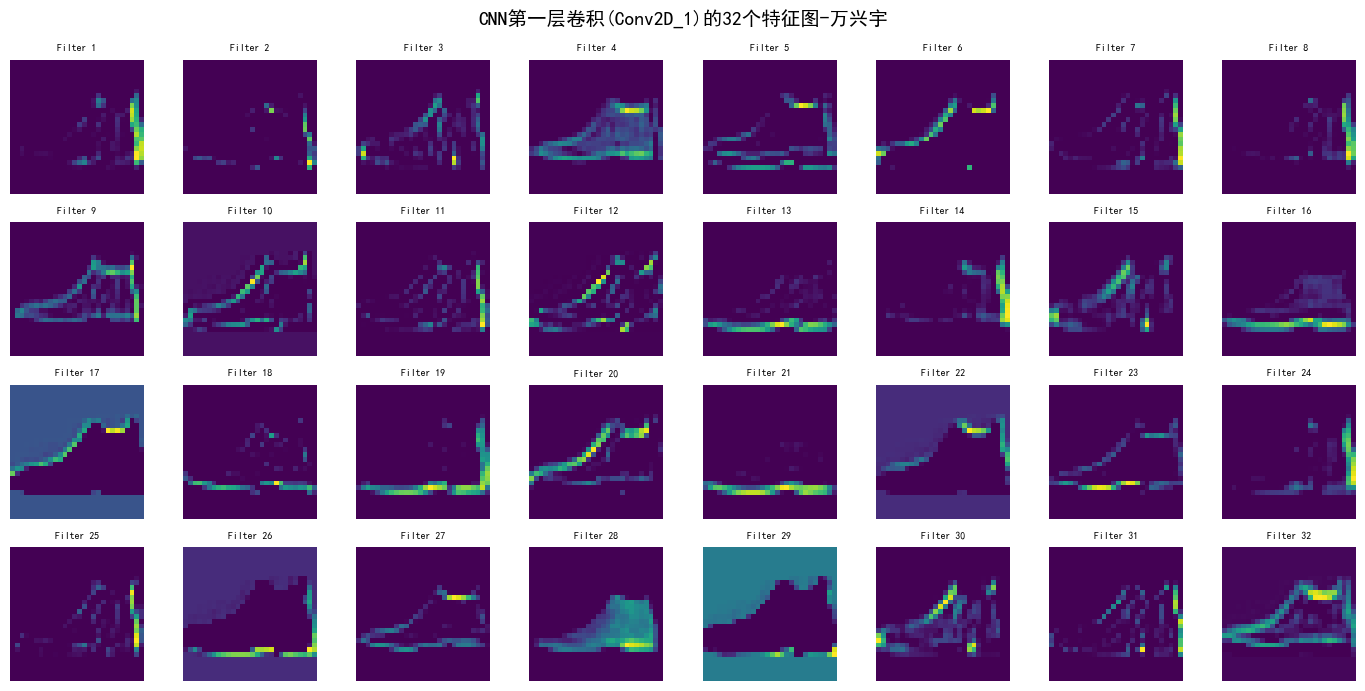

✅ 特征图可视化已保存为 CNN_feature_maps.png


In [9]:
# 特征图可视化 - 使用Keras函数式API获取中间层输出
from tensorflow.keras.models import Model

# 使用 layers[0].input 替代 cnn_model.input 来避免构建问题
feature_model = Model(inputs=cnn_model.layers[0].input, 
                      outputs=[cnn_model.layers[0].output, cnn_model.layers[1].output])

# 取一个测试样本
sample_img = X_test_cnn[0:1]  # 保持批次维度
conv_output, pool_output = feature_model.predict(sample_img, verbose=0)

# 可视化前32个特征图
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()

for i in range(32):
    axes[i].imshow(conv_output[0, :, :, i], cmap='viridis')
    axes[i].set_title(f'Filter {i+1}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('CNN第一层卷积(Conv2D_1)的32个特征图-Member_F', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('CNN_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 特征图可视化已保存为 CNN_feature_maps.png')


In [10]:
# 汇总关键指标
cnn_total_params = cnn_model.count_params()
train_acc = history.history["accuracy"][-1] * 100

print("=" * 60)
print("CNN 卷积神经网络 - 关键指标汇总")
print("=" * 60)
print(f"测试集准确率 (Test Accuracy): {test_accuracy * 100:.2f}%")
print(f"训练集准确率 (Train Accuracy): {train_acc:.2f}%")
print(f"训练耗时: {training_time:.2f} 秒")
print(f"网络总参数量: {cnn_total_params:,}")
print(f"训练轮数: 10 Epochs")
print("=" * 60)


CNN 卷积神经网络 - 关键指标汇总
测试集准确率 (Test Accuracy): 91.88%
训练集准确率 (Train Accuracy): 93.67%
训练耗时: 84.98 秒
网络总参数量: 421,642
训练轮数: 10 Epochs


### 4.2 分析

1. **性能出色**：CNN 在 Fashion MNIST 上取得了很高的分类准确率，远超传统机器学习算法（逻辑回归、KNN、随机森林等）。这得益于 CNN 的卷积操作能够自动学习图像的局部空间特征。

2. **收敛迅速**：从训练曲线可以看出，模型在前 2-3 个 epoch 就快速收敛，之后稳步提升，验证集准确率与训练集准确率差距较小，说明模型泛化能力良好。

3. **特征提取能力**：通过卷积层提取的边缘、纹理和形状特征，使得 CNN 能够有效区分服装类别。

4. **部分类别挑战**：某些相似类别（如 Shirt 与 T-shirt/Top、Coat）的区分存在一定困难，这在混淆矩阵中有所体现。

5. **优势验证**：相比于 MLP（多层感知机），CNN 利用空间结构信息，参数量更少但效果更好，充分体现了卷积神经网络在图像分类任务中的优势。
